# REF_* Measures — Agents Who Improved Energy Standard
Only agents where `BUILD_ES_Old > BUILD_ES_Cur` (numerically), with `Unbekannt` (6) excluded on both sides.

Agenten mit verbessertem Energiestandard: 431


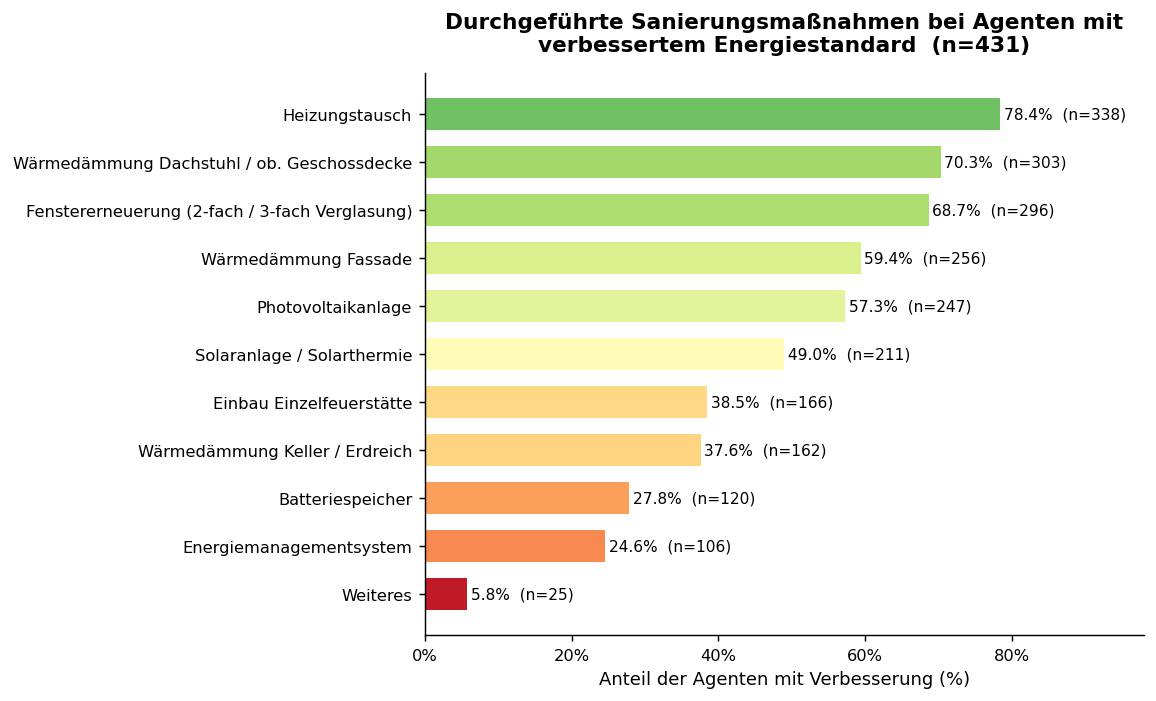

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

with open("../data/processed/survey_v1.1.json") as f:
    data = json.load(f)

# ── Filter: verbesserter Energiestandard, kein Unbekannt ─────────────────────
improved = [
    r for r in data
    if r.get("BUILD_ES_Old") is not None
    and r.get("BUILD_ES_Cur") is not None
    and str(r["BUILD_ES_Old"]) != "6"
    and str(r["BUILD_ES_Cur"]) != "6"
    and int(str(r["BUILD_ES_Old"])) > int(str(r["BUILD_ES_Cur"]))
]
N = len(improved)
print(f"Agenten mit verbessertem Energiestandard: {N}")

# ── REF_* Felder & Bezeichnungen ─────────────────────────────────────────────
ref_fields = [f"REF_{i}" for i in range(1, 12)]
ref_labels = [
    "W\u00e4rmed\u00e4mmung Fassade",
    "W\u00e4rmed\u00e4mmung Dachstuhl / ob. Geschossdecke",
    "W\u00e4rmed\u00e4mmung Keller / Erdreich",
    "Fenstererneuerung (2-fach / 3-fach Verglasung)",
    "Heizungstausch",
    "Einbau Einzelfeuerst\u00e4tte",
    "Solaranlage / Solarthermie",
    "Photovoltaikanlage",
    "Batteriespeicher",
    "Energiemanagementsystem",
    "Weiteres",
]

counts = [sum(1 for r in improved if str(r.get(f, "0")) == "1") for f in ref_fields]
pcts   = [c / N * 100 for c in counts]

# Aufsteigend sortieren
order  = sorted(range(len(pcts)), key=lambda i: pcts[i])
s_lbl  = [ref_labels[i] for i in order]
s_pcts = [pcts[i]       for i in order]
s_cnt  = [counts[i]     for i in order]

# ── Diagramm ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

cmap   = plt.cm.RdYlGn
colors = [cmap(p / 100) for p in s_pcts]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(s_lbl, s_pcts, color=colors, height=0.65)

ax.set_title(
    f"Durchgef\u00fchrte Sanierungsma\u00dfnahmen bei Agenten mit\n"
    f"verbessertem Energiestandard  (n={N})",
    pad=12
)
ax.set_xlabel("Anteil der Agenten mit Verbesserung (%)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, max(s_pcts) * 1.25)

for bar, pct, cnt in zip(bars, s_pcts, s_cnt):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%  (n={cnt})",
        va="center", fontsize=8.5
    )

plt.tight_layout()
plt.show()
